# EDA QsA

# 1. Basic Level EDA Questions

1. What is the total number of apps in the dataset?

2. How many unique categories are there?

3. Which category has the highest number of apps?

4. What is the average rating of all apps?

5. How many apps have a rating greater than 4.5?

6. What is the distribution of app types (Free vs Paid)?

7. What percentage of apps are free?

8. What is the minimum, maximum, and average price of paid apps?

9. Which app has the highest number of reviews?

10. Which app has the highest number of installs?

# LAOD data set 

In [1]:
# ipyplotmport the libraries 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn as sk
import statsmodels as sm 
from statsmodels.formula.api import ols
#this is for jupyter notebook to show the plot in the notebook itself instead of opening a new window for the plot
%matplotlib inline

In [2]:
df = pd.read_csv('./data/googleplaystore.csv')

# 1️⃣ Basic Information

In [3]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Unnamed: 13'],
      dtype='object')

#  2️⃣ Total Number of Apps

In [4]:
df['App'].value_counts().sum()

np.int64(10841)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  int64  
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10841 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10839 non-null  object 
 13  Unnamed: 13     0 non-null      float64
dtypes: float64(2), int64(1), object(11)
memory usage: 1.2+ MB


In [6]:
df.describe()

,Rating,Reviews,Unnamed: 13
count,9367.000000,1.084100e+04,0.0
mean,4.191513,4.441119e+05,NaN
std,0.515735,2.927629e+06,NaN
min,1.000000,0.000000e+00,NaN
25%,4.000000,3.800000e+01,NaN
50%,4.300000,2.094000e+03,NaN
75%,4.500000,5.476800e+04,NaN
max,5.000000,7.815831e+07,NaN


In [7]:
df.isnull().sum().sort_values(ascending=False)


Unnamed: 13       10841
Rating             1474
Current Ver           8
Android Ver           2
Type                  1
Category              1
Genres                1
Size                  0
Reviews               0
App                   0
Installs              0
Price                 0
Content Rating        0
Last Updated          0
dtype: int64

# 3️⃣ Unique Categories

In [8]:
df['Category'].nunique()

33

#  4️⃣ Category with Highest Number of Apps

In [9]:
df['Category'].value_counts().head()

Category
FAMILY      1972
GAME        1144
TOOLS        843
MEDICAL      463
BUSINESS     460
Name: count, dtype: int64

# 5️⃣ Average Rating

In [10]:
df['Rating'].mean()

np.float64(4.191512757553111)

# 6️⃣ Apps with Rating > 4.5

In [11]:
df[df['Rating'] > 4.5].shape[0]

1917

# 7️⃣ Free vs Paid Distribution

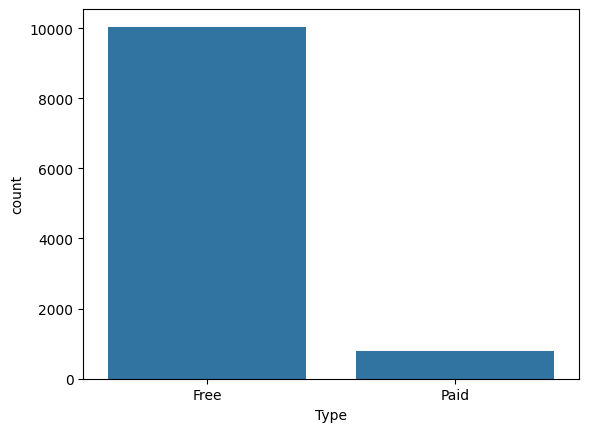

In [12]:
df['Type'].value_counts()

sns.countplot(x='Type', data=df)
plt.show()

# 8️⃣ Percentage of Free Apps

In [13]:
(df['Type'].value_counts(normalize=True) * 100)


Type
Free    92.619926
Paid     7.380074
Name: proportion, dtype: float64

# 9️⃣ Price Analysis (Paid Apps)

In [14]:
df[df['Type'] == 'Paid']['Price'].describe()

count       800
unique       91
top       $0.99
freq        148
Name: Price, dtype: object

# 🔟 Highest Reviews App

In [15]:
df.loc[df['Reviews'].idxmax()]


App                         Facebook
Category                      SOCIAL
Rating                           4.1
Reviews                     78158306
Size              Varies with device
Installs              1,000,000,000+
Type                            Free
Price                              0
Content Rating                  Teen
Genres                        Social
Last Updated          August 3, 2018
Current Ver       Varies with device
Android Ver       Varies with device
Unnamed: 13                      NaN
Name: 2544, dtype: object

# 2. Intermediate Level EDA Questions

1. What is the average rating per category?

2. Which category has the highest average rating?

3. What is the relationship between Reviews and Rating?

4. Do paid apps have higher ratings than free apps?

5. What is the average number of installs per category?

6. Which category generates the highest total revenue?
(Hint: Revenue = Price × Installs)

7. What is the distribution of app sizes?

8. Do larger apps tend to have better ratings?

9. What is the correlation between:

-  Rating and Reviews

- Rating and Installs

- Reviews and Installs

10. Which content rating (Everyone, Teen, etc.) has the most apps?



# 11️⃣ Highest Installs App

In [16]:
df.loc[df['Installs'].idxmax()]

App                  Viber Messenger
Category               COMMUNICATION
Rating                           4.3
Reviews                     11334799
Size              Varies with device
Installs                500,000,000+
Type                            Free
Price                              0
Content Rating              Everyone
Genres                 Communication
Last Updated           July 18, 2018
Current Ver       Varies with device
Android Ver       Varies with device
Unnamed: 13                      NaN
Name: 342, dtype: object

# 12️⃣ Average Rating per Category

In [17]:
df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

Category
EVENTS                 4.435556
EDUCATION              4.389032
ART_AND_DESIGN         4.358065
BOOKS_AND_REFERENCE    4.346067
PERSONALIZATION        4.335987
PARENTING              4.300000
GAME                   4.286326
BEAUTY                 4.278571
HEALTH_AND_FITNESS     4.277104
SHOPPING               4.259664
SOCIAL                 4.255598
WEATHER                4.244000
SPORTS                 4.223511
PRODUCTIVITY           4.211396
HOUSE_AND_HOME         4.197368
FAMILY                 4.192272
PHOTOGRAPHY            4.192114
AUTO_AND_VEHICLES      4.190411
MEDICAL                4.189143
LIBRARIES_AND_DEMO     4.178462
FOOD_AND_DRINK         4.166972
COMMUNICATION          4.158537
COMICS                 4.155172
NEWS_AND_MAGAZINES     4.132189
FINANCE                4.131889
ENTERTAINMENT          4.126174
BUSINESS               4.121452
TRAVEL_AND_LOCAL       4.109292
LIFESTYLE              4.094904
VIDEO_PLAYERS          4.063750
MAPS_AND_NAVIGATION    4.051613

# 13️⃣ Reviews vs Rating Relationship

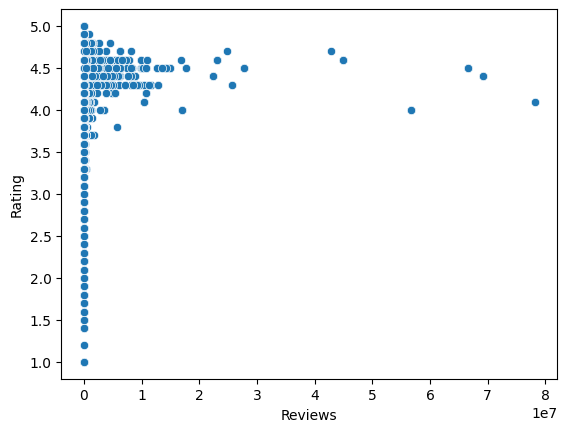

In [18]:
sns.scatterplot(x='Reviews', y='Rating', data=df)
plt.show()

# 14️⃣ Paid vs Free Rating Comparison

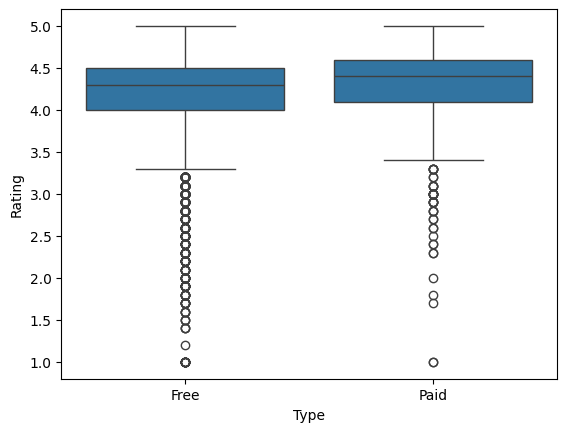

In [19]:

df.groupby('Type')['Rating'].mean()

sns.boxplot(x='Type', y='Rating', data=df)
plt.show()

# Removing + and , sign From Install column

In [20]:
df['Installs'].value_counts()

Installs
1,000,000+        1579
10,000,000+       1252
100,000+          1169
10,000+           1054
1,000+             908
5,000,000+         752
100+               719
500,000+           539
50,000+            479
5,000+             477
100,000,000+       409
10+                386
500+               330
50,000,000+        289
50+                205
5+                  82
500,000,000+        72
1+                  67
1,000,000,000+      58
0+                  14
0                    1
Name: count, dtype: int64

In [21]:
df['Installs'] = df['Installs'].apply(lambda x: x.replace('+', '') if '+' in str(x) else x)

In [22]:
df['Installs'] = df['Installs'].apply(lambda x: x.replace(',', '') if ',' in str(x) else x)


# Convert to integer

In [23]:
df['Installs'] = df['Installs'].apply(lambda x: int(x))

In [24]:
df['Installs'].value_counts()

Installs
1000000       1579
10000000      1252
100000        1169
10000         1054
1000           908
5000000        752
100            719
500000         539
50000          479
5000           477
100000000      409
10             386
500            330
50000000       289
50             205
5               82
500000000       72
1               67
1000000000      58
0               15
Name: count, dtype: int64

#  15️⃣ Average Installs per Category


In [25]:
df.groupby('Category')['Installs'].mean().sort_values(ascending=False)

Category
COMMUNICATION          8.435989e+07
SOCIAL                 4.769447e+07
VIDEO_PLAYERS          3.555430e+07
PRODUCTIVITY           3.343418e+07
GAME                   3.066960e+07
PHOTOGRAPHY            3.011417e+07
TRAVEL_AND_LOCAL       2.662359e+07
NEWS_AND_MAGAZINES     2.648876e+07
ENTERTAINMENT          1.925611e+07
TOOLS                  1.358573e+07
SHOPPING               1.249173e+07
BOOKS_AND_REFERENCE    8.318050e+06
PERSONALIZATION        5.932385e+06
EDUCATION              5.586231e+06
MAPS_AND_NAVIGATION    5.286729e+06
FAMILY                 5.201959e+06
WEATHER                5.196348e+06
HEALTH_AND_FITNESS     4.642441e+06
SPORTS                 4.560350e+06
FINANCE                2.395215e+06
BUSINESS               2.178076e+06
FOOD_AND_DRINK         2.156683e+06
HOUSE_AND_HOME         1.917187e+06
ART_AND_DESIGN         1.912894e+06
LIFESTYLE              1.407444e+06
DATING                 1.129533e+06
COMICS                 9.347692e+05
LIBRARIES_AND_DEMO 

# Again Removing $ sign from 'Price' column

In [26]:
df['Price'].value_counts()

Price
0          10041
$0.99        148
$2.99        129
$1.99         73
$4.99         72
           ...  
$3.61          1
$394.99        1
$1.26          1
$1.20          1
$1.04          1
Name: count, Length: 92, dtype: int64

# Convert to Integer

In [27]:
df['Price'] = df['Price'].apply(lambda x: x.replace('$', '') if '$' in str(x) else x)
df['Price'] = df['Price'].apply(lambda x: float(x))

In [28]:
df['Price'].value_counts()

Price
0.00      10041
0.99        148
2.99        129
1.99         73
4.99         72
          ...  
3.61          1
394.99        1
1.26          1
1.20          1
1.04          1
Name: count, Length: 92, dtype: int64

# 16️⃣ Revenue Calculation

In [29]:

df['Revenue'] = df['Price'] * df['Installs']

df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

Category
FAMILY                 1.860526e+08
LIFESTYLE              5.758394e+07
GAME                   4.098764e+07
FINANCE                2.572668e+07
PHOTOGRAPHY            2.092277e+07
MEDICAL                1.357484e+07
PERSONALIZATION        1.027695e+07
TOOLS                  5.464821e+06
SPORTS                 4.706212e+06
PRODUCTIVITY           4.313375e+06
COMMUNICATION          4.247364e+06
WEATHER                4.181380e+06
EDUCATION              2.403980e+06
BUSINESS               2.048543e+06
HEALTH_AND_FITNESS     1.725069e+06
MAPS_AND_NAVIGATION    1.240789e+06
TRAVEL_AND_LOCAL       1.151504e+06
ENTERTAINMENT          7.980000e+05
VIDEO_PLAYERS          3.352900e+05
FOOD_AND_DRINK         2.844000e+05
PARENTING              2.499590e+05
AUTO_AND_VEHICLES      1.001485e+05
BOOKS_AND_REFERENCE    9.022674e+04
DATING                 8.836150e+04
ART_AND_DESIGN         3.184000e+04
SHOPPING               3.014900e+04
NEWS_AND_MAGAZINES     6.445000e+03
SOCIAL             

- We have 8830 values in M units
- We have 316 values in k units
- We have 1695 value in Varies with device
- Let's convert the M and K units into bytes and then remove the M and K from the values and convert them into numeric data type.

In [30]:
df['Size'].value_counts()

Size
Varies with device    1695
11M                    198
12M                    196
14M                    194
13M                    191
                      ... 
470k                     1
975k                     1
980k                     1
404k                     1
420k                     1
Name: count, Length: 461, dtype: int64

In [31]:
# find the values in size column which has 'M' in it
df['Size'].loc[df['Size'].str.contains('M')].value_counts().sum()

np.int64(8830)

In [32]:
# find the values in size column which has 'KB' in it
df['Size'].loc[df['Size'].str.contains('k')].value_counts().sum()

np.int64(316)

In [33]:
# convert the size column to numeric by multiplying the values with 1024 if it has 'k' in it and 1024*1024 if it has 'M' in it
# this function will convert the size column to numeric
def convert_size(size):
    # add function details here
    '''
    This function will convert the size column to numeric by multiplying the values with 1024 if it has 'k' in it and 1024*1024 if it has 'M' in it
    '''
    
    if isinstance(size, str):
        if 'k' in size:
            return float(size.replace('k', '')) * 1024
        elif 'M' in size:
            return float(size.replace('M', '')) * 1024 * 1024
        elif 'Varies with device' in size:
            return np.nan
    return size

df['Size'] = df['Size'].apply(convert_size)

In [ ]:
# rename the column name 'Size' to 'Size_in_bytes'
df.rename(columns={'Size': 'Size_in_bytes'}, inplace=True)


In [ ]:
# making a new column called 'Size in Mb' which will have the size in MB
df['Size_in_Mb'] = df['Size_in_bytes'].apply(lambda x: x/(1024*1024))

In [ ]:
df['Size_in_Mb'].value_counts()

Size_in_Mb
11.000000    198
12.000000    196
14.000000    194
13.000000    191
15.000000    184
            ... 
0.539062       1
0.864258       1
0.996094       1
0.568359       1
0.604492       1
Name: count, Length: 459, dtype: int64

# 17️⃣ App Size Distribution

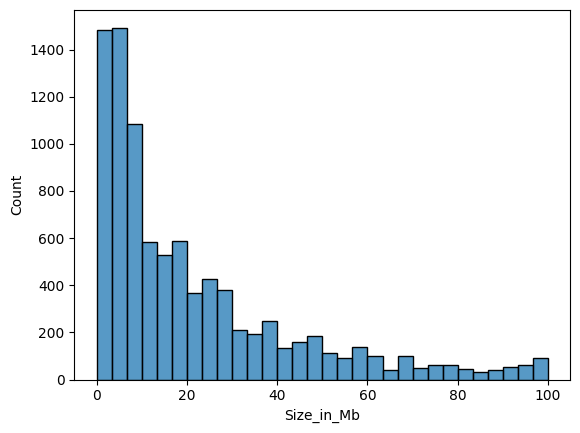

In [ ]:
sns.histplot(df['Size_in_Mb'], bins=30)
plt.show()


# 18️⃣ Size vs Rating

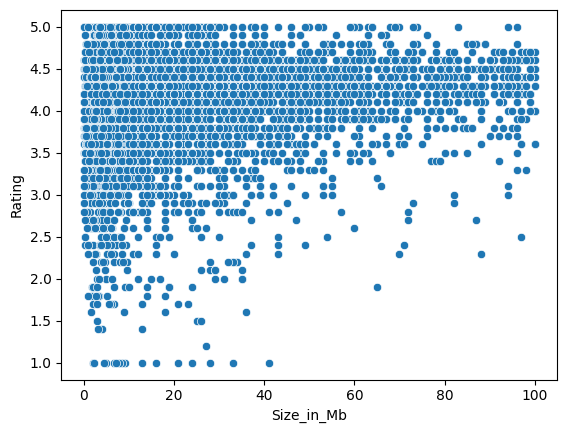

In [ ]:
sns.scatterplot(x='Size_in_Mb', y='Rating', data=df)
plt.show()

# 19️⃣ Correlation Matrix

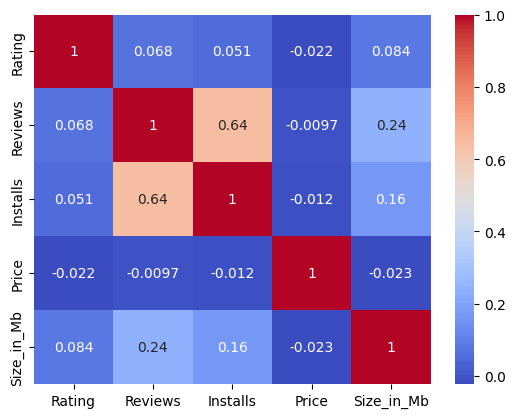

In [ ]:
corr = df[['Rating', 'Reviews', 'Installs', 'Price', 'Size_in_Mb']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# 🔹 Advanced Level EDA Questions
- Are highly installed apps generally free or paid?

- What is the install distribution across price ranges?

- Which category has the highest median installs?

- Identify outliers in:

- Rating

- Reviews

- Installs

- Does updating an app recently affect its rating?

- Which Android version supports the highest-rated apps?

- What is the trend of app updates over time?

- Are paid apps generally larger in size than free apps?

- Build a pivot table showing:

- `Category vs Average Rating`

- `Category vs Total Installs`

- Based on EDA, which category would you recommend for launching a new app and why?

# 20️⃣ Content Rating Distribution

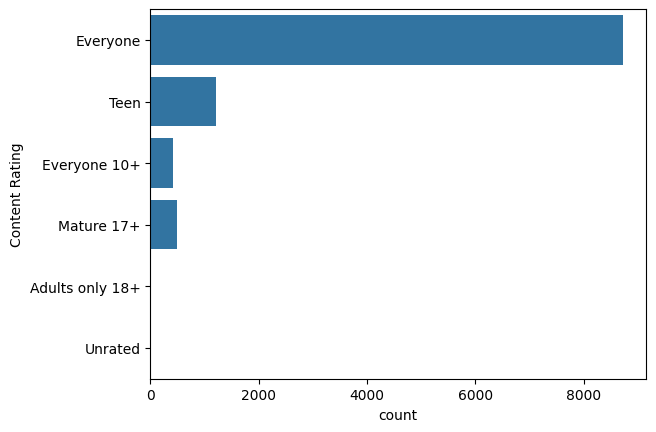

In [ ]:

df['Content Rating'].value_counts()

sns.countplot(y='Content Rating', data=df)
plt.show()

# 21️⃣ Free vs Paid in Highly Installed Apps

In [ ]:
high_installs = df[df['Installs'] > df['Installs'].quantile(0.75)]
high_installs['Type'].value_counts()

Type
Free    2077
Paid       3
Name: count, dtype: int64

# 22️⃣ Install Distribution

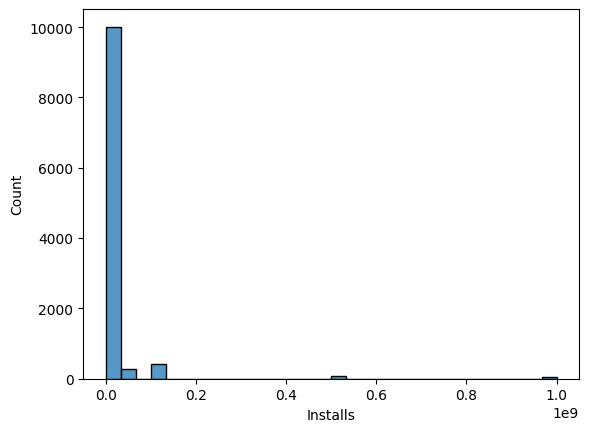

In [ ]:
sns.histplot(df['Installs'], bins=30)
plt.show()

# 23️⃣ Median Installs per Category

In [ ]:
df.groupby('Category')['Installs'].median().sort_values(ascending=False)

Category
ENTERTAINMENT          5000000.0
PHOTOGRAPHY            5000000.0
SHOPPING               1000000.0
GAME                   1000000.0
EDUCATION              1000000.0
WEATHER                1000000.0
SOCIAL                 1000000.0
VIDEO_PLAYERS          1000000.0
COMMUNICATION          1000000.0
TRAVEL_AND_LOCAL       1000000.0
HOUSE_AND_HOME          500000.0
HEALTH_AND_FITNESS      500000.0
FOOD_AND_DRINK          500000.0
PRODUCTIVITY            300000.0
ART_AND_DESIGN          100000.0
COMICS                  100000.0
AUTO_AND_VEHICLES       100000.0
PARENTING               100000.0
NEWS_AND_MAGAZINES      100000.0
SPORTS                  100000.0
MAPS_AND_NAVIGATION     100000.0
FAMILY                  100000.0
DATING                  100000.0
BEAUTY                   50000.0
FINANCE                  50000.0
TOOLS                    50000.0
LIFESTYLE                10000.0
BOOKS_AND_REFERENCE      10000.0
PERSONALIZATION          10000.0
LIBRARIES_AND_DEMO       10000.0
B

# 24️⃣ Detect Outliers (Boxplot)

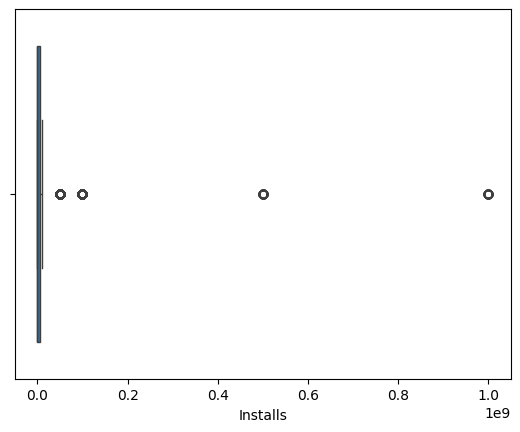

In [ ]:
sns.boxplot(x=df['Installs'])
plt.show()

# 25️⃣ Update Trend

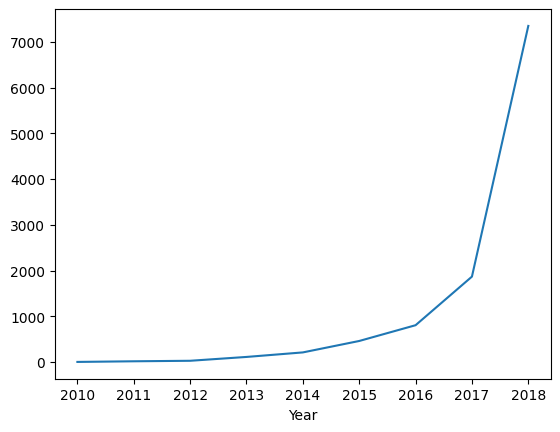

In [ ]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'])

df['Year'] = df['Last Updated'].dt.year

df['Year'].value_counts().sort_index().plot(kind='line')
plt.show()

# 26️⃣ Android Version vs Rating


In [ ]:

df.groupby('Android Ver')['Rating'].mean().sort_values(ascending=False).head()

Android Ver
7.0 - 7.1.1    4.500000
5.0 - 8.0      4.500000
5.0 - 6.0      4.500000
4.4W and up    4.383333
2.0 and up     4.370370
Name: Rating, dtype: float64

# 27️⃣ Pivot Table

In [ ]:

pd.pivot_table(df,
               values=['Rating', 'Installs'],
               index='Category',
               aggfunc={'Rating':'mean', 'Installs':'sum'})

,Installs,Rating
Category,,
ART_AND_DESIGN,124338100,4.358065
AUTO_AND_VEHICLES,53130211,4.190411
BEAUTY,27197050,4.278571
BOOKS_AND_REFERENCE,1921469576,4.346067
BUSINESS,1001914865,4.121452
COMICS,56086150,4.155172
COMMUNICATION,32647276251,4.158537
DATING,264310807,3.970769
EDUCATION,871452000,4.389032


# 28️⃣ Top Category Recommendation Logic

In [ ]:
recommend = df.groupby('Category').agg({
    'Rating':'mean',
    'Installs':'sum',
    'Revenue':'sum'
}).sort_values(by='Installs', ascending=False)

recommend.head()

,Rating,Installs,Revenue
Category,,,
GAME,4.286326,35086024415,40987636.85
COMMUNICATION,4.158537,32647276251,4247364.50
PRODUCTIVITY,4.211396,14176091369,4313374.95
SOCIAL,4.255598,14069867902,5940.00
TOOLS,4.047411,11452771915,5464820.59


# 29️⃣ Preprocessing Before Modeling

In [ ]:
# Handle missing
df.fillna(0, inplace=True)

# Encode categorical
df_encoded = pd.get_dummies(df, drop_first=True)

# 30️⃣ Feature Selection for Rating Prediction


In [ ]:

features = ['Reviews', 'Installs', 'Price', 'Size_in_Mb']
X = df[features]
y = df['Rating']
print(y.value_counts())

Rating
0.0    1474
4.4    1109
4.3    1076
4.5    1038
4.2     952
4.6     823
4.1     708
4.0     568
4.7     499
3.9     386
3.8     303
5.0     274
3.7     239
4.8     234
3.6     174
3.5     163
3.4     128
3.3     102
4.9      87
3.0      83
3.1      69
3.2      64
2.9      45
2.8      42
2.7      25
2.6      25
2.5      21
2.3      20
2.4      19
1.0      16
1.9      14
2.2      14
2.0      12
1.7       8
1.8       8
2.1       8
1.6       4
1.4       3
1.5       3
1.2       1
Name: count, dtype: int64


In [ ]:
df.columns